<p>The Seoul Bike Sharing Demand dataset about how many public bikes were rented in Seoul. It includes weather, date, season, holiday, and working hour information.<br>
The main goal is to predict the number of rented bikes each hour, so the city can keep enough bikes available for people.</p>

<p>Source of dataset: https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand<br></p>


In [2]:
# In this notebook, the demand is predicted only when system is functional.
# The dataset seems to be clean, but there is only one annual cycle. I can not prove that seasonal behavior repeats next year.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance


from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, SplineTransformer


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone


from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

<h3><center>Loading and exploring the dataset<h3>

In [4]:
# Some columns's names have symbols, so  I need text encoding.  
df = pd.read_csv("seoul+bike+sharing+demand/SeoulBikeData.csv", encoding="cp1252")
df.shape

(8760, 14)

In [5]:
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [6]:
df.columns

Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Holiday', 'Functioning Day'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   str    
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   str    
 12  Holiday                    8760 non-null   str    
 13  Functioning Day            8760 non-null   str    
dtypes: 

###  Cleaning names 

In [8]:
# In this cell, I am gonna clean the names of the columns and convert the date column to datetime format.
df.columns = ['date', 'rented_bike_count', 'hour', "temperature_c", "humidity_percent",  "wind_speed_m_s",  "visibility_10m",
              "dew_point_temperature_c", "solar_radiation_mj_m2", "rainfall_mm", 'snowfall_cm', 'season', "holiday", "functioning_day"]  


### Building the hourly timestamp

In [9]:
df["date"] = pd.to_datetime(df["date"], format="%d/%m/%Y", errors="raise")

# I can combine the date and hour columns to create  datetime column.
df["datetime"] = df["date"] + pd.to_timedelta(df["hour"], unit="h")
df = df.sort_values('datetime').reset_index(drop=True)
# For better understanding, let's move the datetime column to the first column.
df = df[["datetime"] + [column for column in df.columns if column != 'datetime']]
# I dont need the date and hour columns anymore, so I will drop them.
df = df.drop(["date"],axis=1)
df.head()

,datetime,rented_bike_count,hour,temperature_c,humidity_percent,wind_speed_m_s,visibility_10m,dew_point_temperature_c,solar_radiation_mj_m2,rainfall_mm,snowfall_cm,season,holiday,functioning_day
0,2017-12-01 00:00:00,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,2017-12-01 01:00:00,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,2017-12-01 02:00:00,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,2017-12-01 03:00:00,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,2017-12-01 04:00:00,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [10]:
# From info() I can see that there are no missing values.
# let's check if there are any duplicated rows.
df.duplicated().sum()

np.int64(0)

In [11]:
# let's check the unique values of each column.
for column in df.columns:
    print(f'{column}: {df[column].nunique()} unique values')

datetime: 8760 unique values
rented_bike_count: 2166 unique values
hour: 24 unique values
temperature_c: 546 unique values
humidity_percent: 90 unique values
wind_speed_m_s: 65 unique values
visibility_10m: 1789 unique values
dew_point_temperature_c: 556 unique values
solar_radiation_mj_m2: 345 unique values
rainfall_mm: 61 unique values
snowfall_cm: 51 unique values
season: 4 unique values
holiday: 2 unique values
functioning_day: 2 unique values


In [12]:
# Let's check whereever the timestamp changes by one hour each row. 
gap_hours = df["datetime"].diff().dt.total_seconds() / 3600
print(gap_hours.value_counts())

# time range of the DS, from beginning to end.
print(f"Time range: {df['datetime'].min()} to {df['datetime'].max()}")
# Excactly one year of data

datetime
1.0    8759
Name: count, dtype: int64
Time range: 2017-12-01 00:00:00 to 2018-11-30 23:00:00


In [13]:
df.select_dtypes("number").describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
rented_bike_count,8760.0,704.60,645.00,0.0,191.00,504.50,1065.25,3556.00
hour,8760.0,11.50,6.92,0.0,5.75,11.50,17.25,23.00
temperature_c,8760.0,12.88,11.94,-17.8,3.50,13.70,22.50,39.40
humidity_percent,8760.0,58.23,20.36,0.0,42.00,57.00,74.00,98.00
wind_speed_m_s,8760.0,1.72,1.04,0.0,0.90,1.50,2.30,7.40
visibility_10m,8760.0,1436.83,608.30,27.0,940.00,1698.00,2000.00,2000.00
dew_point_temperature_c,8760.0,4.07,13.06,-30.6,-4.70,5.10,14.80,27.20
solar_radiation_mj_m2,8760.0,0.57,0.87,0.0,0.00,0.01,0.93,3.52
rainfall_mm,8760.0,0.15,1.13,0.0,0.00,0.00,0.00,35.00
snowfall_cm,8760.0,0.08,0.44,0.0,0.00,0.00,0.00,8.80


In [14]:
# The weather columns  have  wide range of values. 
# temperature_c from -17 to 39 
# humidity_percent from 0 to 98 
# visibility_10m from 27 to 20000, this is extremely std is high.
# solar_radiation_mj_m2 from 0 to 3.52. 25%  is 0 and 50 % is 0.01, this makes sense because of night time.
# Most of the times, there is no rainfall and snowfall, but in some cases, there is heavy rainfall and snowfall.

# When I research about the Seoul weather, I found that these values are realistic for Seoul. Cold winters and hot summers.

In [15]:
# Let's check the amount of zero values inb demand column.
zero_demand_share = df["rented_bike_count"].eq(0).mean()  
print(f"Share of zero demand hours: {zero_demand_share:.2%}")

Share of zero demand hours: 3.37%


<h3><center>EDA<h3>

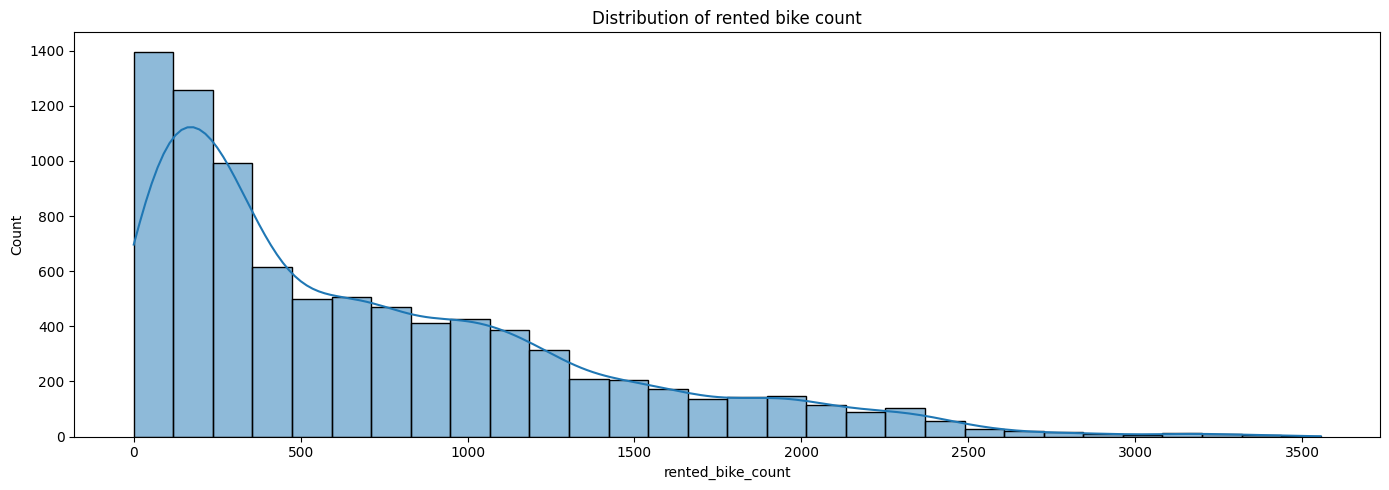

In [16]:
# Let's check the distribution of the target variable, rented_bike_count.  
plt.figure(figsize=(14, 5))
sns.histplot(data=df, x="rented_bike_count", bins=30, kde=True)
plt.title("Distribution of rented bike count")
plt.tight_layout()
plt.show()

In [17]:
# As I expected, the distribution of rented bike count is right skewed.
# Most of the time, the rented bike count is low, but there are some days with high rented bike count.

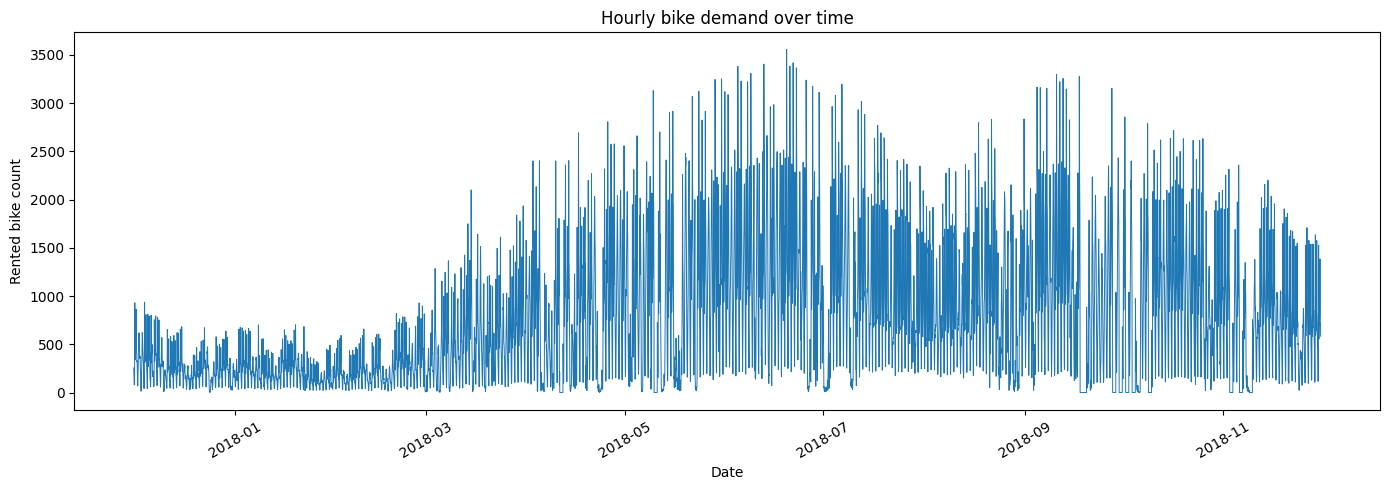

In [18]:
# Let's check visually how the demand rate changes over time.
plt.figure(figsize=(14, 5))
sns.lineplot( data=df, x="datetime", y="rented_bike_count", estimator=None, errorbar=None, linewidth=0.7)

plt.title("Hourly bike demand over time")
plt.xlabel("Date")
plt.ylabel("Rented bike count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [19]:
# During summer months, the demand is higher than winter months. 

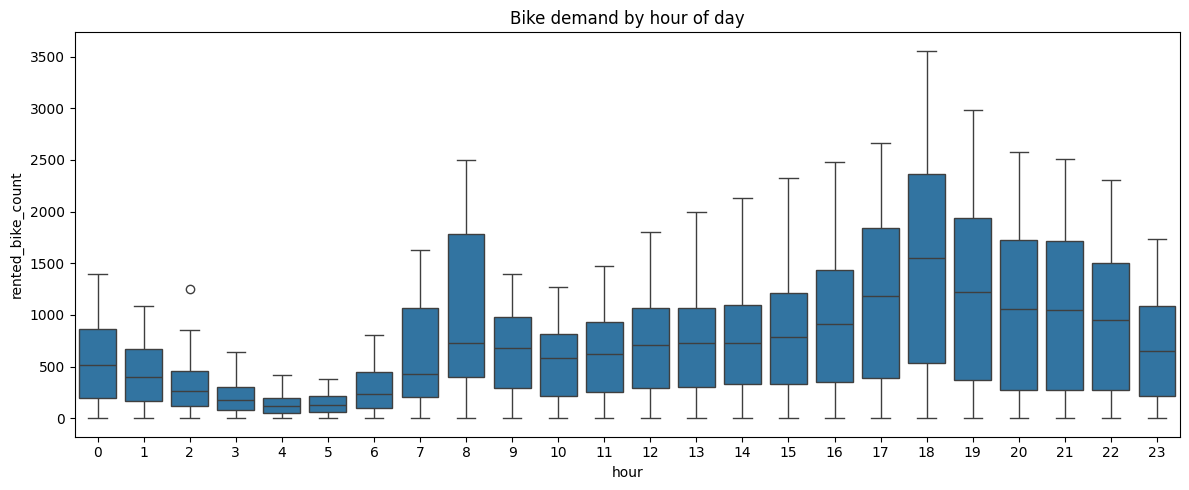

In [20]:
# Let's check the hourly pattern of the demand.
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="hour", y="rented_bike_count")

plt.title("Bike demand by hour of day")
plt.tight_layout()
plt.show()

In [21]:
# From 7-8 am demand is high,  I guess this is because of people going to work and school
# After that demand is lower until 16 because of people are at work and school.
# After 16 again demand is high because of people going back home or going out 

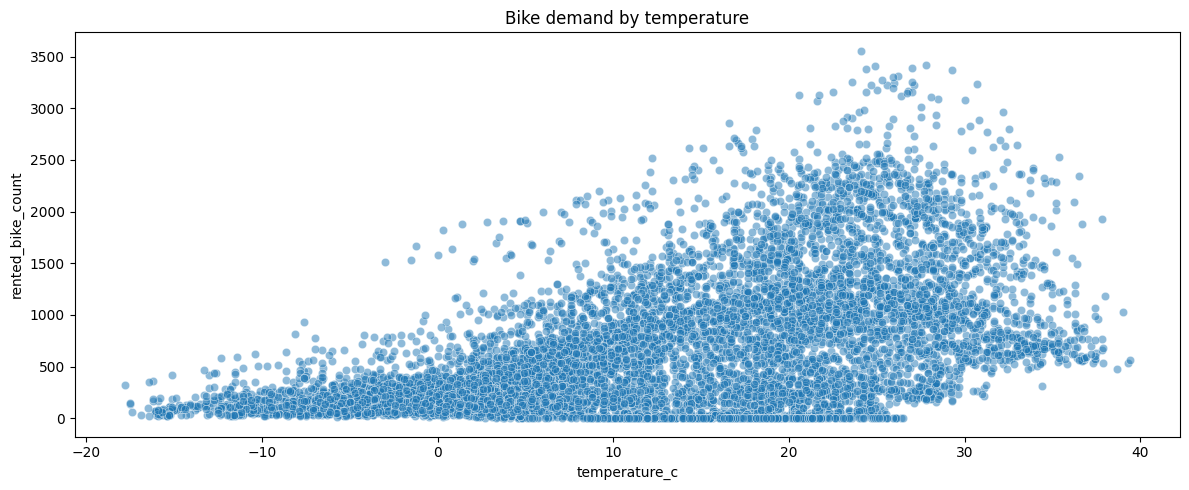

In [22]:
# Let's which weather conditions are more favorable for bike.
plt.figure(figsize=(12, 5))
sns.scatterplot(data=df, x="temperature_c",y="rented_bike_count", alpha=0.5)
plt.title("Bike demand by temperature")
plt.tight_layout()
plt.show()

In [23]:
# The above scatter plot makes sense, in higher temperatures, the demand is higher and in very high temperatures, the demand drops because of the heat. 

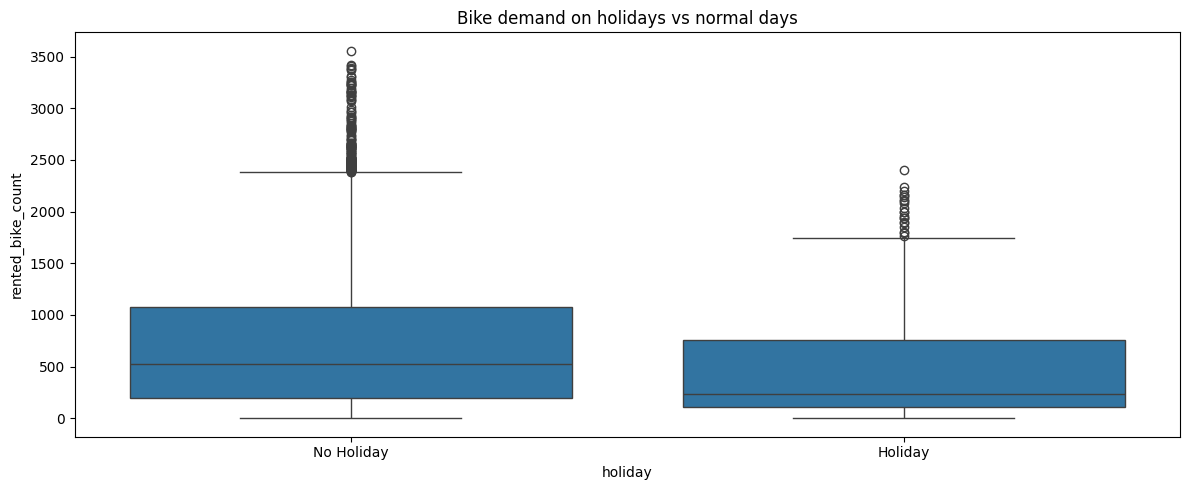

In [24]:
# let's visualize the holidays and normal days.
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="holiday", y="rented_bike_count")
plt.title("Bike demand on holidays vs normal days")
plt.tight_layout()
plt.show()

In [25]:
# I am gonna check the share rate of the holiday days in the DS.
holiday_share = df['holiday'].eq("Holiday").mean()
print(f"Holiday share in the dataset:{holiday_share:.2%}")

Holiday share in the dataset:4.93%


In [26]:
# Interesting, share of the holiday days is only 4.9%. By total the gap between holiday and normal days is not that big.
# This makes sense. 

In [27]:
# Let's find out the maximum and minimum rainfall and snowfall values
# I found that Rainfall column has 61 unique values,
# Snowfall column has 51 unique values. 
# I am gonna group their values for better visualization in the next cells.
print(f"Rainfall mm: min={df['rainfall_mm'].min()}, max={df['rainfall_mm'].max()}")
print(f"Snowfall cm: min={df['snowfall_cm'].min()}, max={df['snowfall_cm'].max()}")

Rainfall mm: min=0.0, max=35.0
Snowfall cm: min=0.0, max=8.8


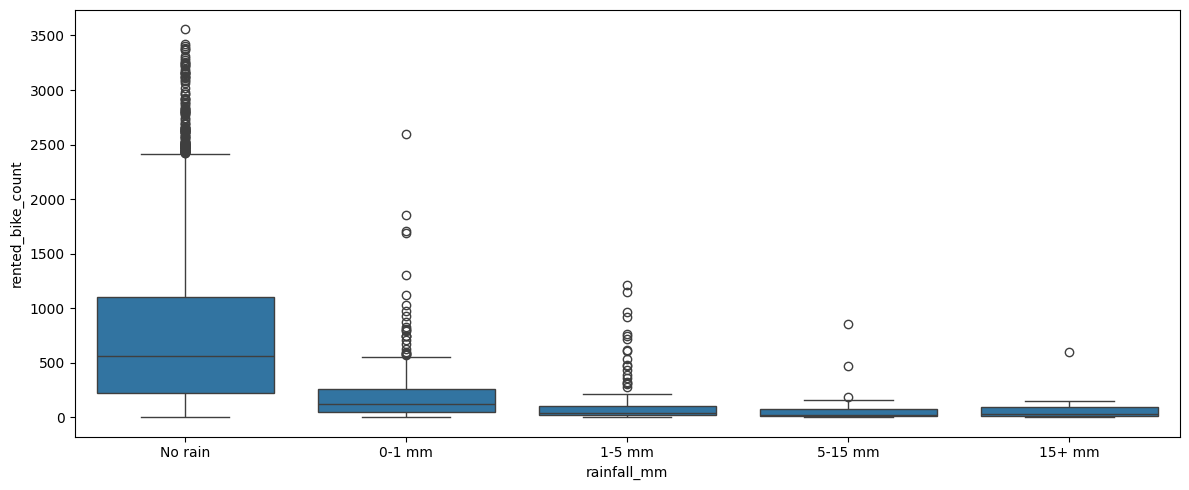

In [28]:
# Let's visualize what happened in rainy and snowy days.
plt.figure(figsize=(12, 5))
rain_group = pd.cut(df["rainfall_mm"],  bins=[-0.01, 0, 1, 5, 15, float("inf")], labels=["No rain", "0-1 mm", "1-5 mm", "5-15 mm", "15+ mm"])
sns.boxplot(x=rain_group, y=df["rented_bike_count"])
plt.tight_layout()
plt.show()

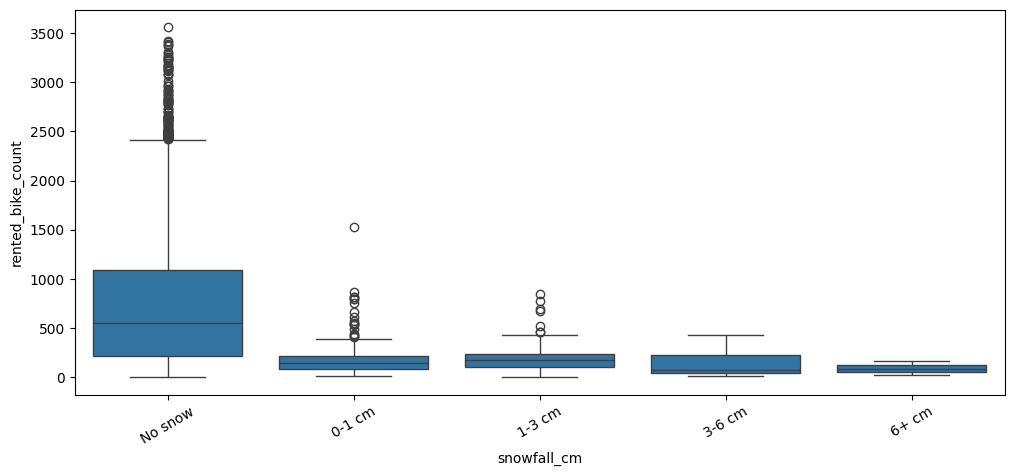

In [29]:
# Let's visualize what happened in rainy and snowy days.
# In previous cell, I found that snowfall has 51 unique values, so I will group them into 5 groups.
plt.figure(figsize=(12, 5))
snow_group = pd.cut(df["snowfall_cm"], bins=[-0.1, 0, 1, 3, 6, 10], labels=["No snow", "0-1 cm", "1-3 cm", "3-6 cm", "6+ cm"])
sns.boxplot(x=snow_group, y=df["rented_bike_count"])
plt.xticks(rotation=30)
plt.show()

In [30]:
# In both boxplots, in non rainy and non snowy days, the demand is higher
# By snowfall cm and rainfall mm going up, the demand is going down. 

<h3><center> Preprocessing<h3>

In [31]:
df.head(10)

,datetime,rented_bike_count,hour,temperature_c,humidity_percent,wind_speed_m_s,visibility_10m,dew_point_temperature_c,solar_radiation_mj_m2,rainfall_mm,snowfall_cm,season,holiday,functioning_day
0,2017-12-01 00:00:00,254,0,-5.2,37,2.2,2000,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes
1,2017-12-01 01:00:00,204,1,-5.5,38,0.8,2000,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes
2,2017-12-01 02:00:00,173,2,-6.0,39,1.0,2000,-17.7,0.00,0.0,0.0,Winter,No Holiday,Yes
3,2017-12-01 03:00:00,107,3,-6.2,40,0.9,2000,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes
4,2017-12-01 04:00:00,78,4,-6.0,36,2.3,2000,-18.6,0.00,0.0,0.0,Winter,No Holiday,Yes
5,2017-12-01 05:00:00,100,5,-6.4,37,1.5,2000,-18.7,0.00,0.0,0.0,Winter,No Holiday,Yes
6,2017-12-01 06:00:00,181,6,-6.6,35,1.3,2000,-19.5,0.00,0.0,0.0,Winter,No Holiday,Yes
7,2017-12-01 07:00:00,460,7,-7.4,38,0.9,2000,-19.3,0.00,0.0,0.0,Winter,No Holiday,Yes
8,2017-12-01 08:00:00,930,8,-7.6,37,1.1,2000,-19.8,0.01,0.0,0.0,Winter,No Holiday,Yes
9,2017-12-01 09:00:00,490,9,-6.5,27,0.5,1928,-22.4,0.23,0.0,0.0,Winter,No Holiday,Yes


In [32]:
# I am thinking about functional day column that should I keep it or not. 
# If I want to predict the demand for functional days and non functional days, I can keep it. 
# But if I want to predict the demand only when the system is functioning, I can drop it.  

print('Shape before filtering', df.shape)
df = df[df["functioning_day"] == "Yes"].reset_index(drop=True)
print('Shape after filtering', df.shape)

# Now function day column has only one unique value, so I can drop it.
df = df.drop(columns=["functioning_day"])

Shape before filtering (8760, 14)
Shape after filtering (8465, 14)


In [33]:
# I found that in previous cell, denmand columns has 0 values, I am wondering that are these 0 values related to non functioning days.
# Since I filtered the non functioning days. Do I have any 0 values in demand column?
zero_rows = df[df["rented_bike_count"] == 0]
print(f"Number of rows with zero demand: {len(zero_rows)}") 

Number of rows with zero demand: 0


In [34]:
df.columns

Index(['datetime', 'rented_bike_count', 'hour', 'temperature_c',
       'humidity_percent', 'wind_speed_m_s', 'visibility_10m',
       'dew_point_temperature_c', 'solar_radiation_mj_m2', 'rainfall_mm',
       'snowfall_cm', 'season', 'holiday'],
      dtype='str')

In [35]:
# In this cell, I am gonna extract month and day of week
df['dayofweek'] = df['datetime'].dt.dayofweek
df["day_of_year"] = df["datetime"].dt.dayofyear

In [36]:
df = df.drop('season', axis=1)

In [37]:
# Maping the holiday column to binary values.

df["holiday"] = df["holiday"].map({"Holiday": 1, "No Holiday": 0})

In [38]:
# I am gonna check the multicollinearity of the features by calculating the vif 
numeric_column = df.drop(columns=["rented_bike_count", "datetime"]).select_dtypes("number")
vif = pd.DataFrame()
vif["feature"] = numeric_column.columns
vif['vif'] =[variance_inflation_factor(numeric_column.values, i) for i in range(numeric_column.shape[1])]

vif.sort_values("vif", ascending=False)

,feature,vif
1,temperature_c,35.409653
5,dew_point_temperature_c,18.615675
4,visibility_10m,9.296548
2,humidity_percent,7.632706
3,wind_speed_m_s,4.898883
0,hour,4.421162
11,day_of_year,4.361501
10,dayofweek,3.284985
6,solar_radiation_mj_m2,2.864002
8,snowfall_cm,1.139198


In [39]:
# It seems that weather columns overlap each other, what I can see from the VIF

#### Hadling noise

In [40]:
noise_data  = df[df['humidity_percent'] == 0][['datetime', "humidity_percent", 'temperature_c',
                                              "dew_point_temperature_c", "rented_bike_count"]]

print(f"rows with zero humidity: {len(noise_data)}")
noise_data.head()

rows with zero humidity: 17


,datetime,humidity_percent,temperature_c,dew_point_temperature_c,rented_bike_count
4015,2018-05-19 07:00:00,0,11.4,4.5,436
4058,2018-05-21 02:00:00,0,13.9,-2.1,262
4059,2018-05-21 03:00:00,0,13.0,-2.5,165
4060,2018-05-21 04:00:00,0,12.4,-3.4,113
4061,2018-05-21 05:00:00,0,11.9,-2.7,200


In [41]:
# zero humidity is not possible in the natural and real world environment. 
# So I am gonna fix these 17 suspicious rows
# For now I am gonna replace the zero values with NaN, and I will impute them later.
df.loc[df["humidity_percent"].eq(0), 'humidity_percent'] = np.nan

### Creating cyclic


In [42]:
# Creating cyclical features for hour and month.
#df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
#df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
#df["month_cos"] = np.cos(2 * np.pi * df['month'] / 12)
#df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)

# Later on, I noticed that cyclic encoding was not good for this dataset, pair sin/cos describes smooth patterns.
# In my previous cells, in  EDA section, for example the hour column has many peaks during 24 hours: morning peak and  evening peak. 
# Because of sinusoidal cycle.

# The better option is to use one hot encoding for hour inside the pipeline, that every hour has its own effect. 

### Spliting based on calender 

In [43]:
# Splitting the dataset into train, validation and test

train_df = df.loc[df['datetime'] < "2018-08-01"]
validation_df = df.loc[(df["datetime"] >= "2018-08-01") & (df["datetime"] < "2018-10-01")]
test_df = df.loc[df["datetime"] >= "2018-10-01"]

target_column = 'rented_bike_count'
time_column = 'datetime'

# let's print train ds, validation ds and test ds
print(f'Train dataset shape: {train_df.shape}')
print(f"Target mean in train dataset: {train_df[target_column].mean():.2f}")
print(f"Target median in train dataset: {train_df[target_column].median():.2f}")
print(f"\nValidation dataset shape: {validation_df.shape}")
print(f"Target mean in validation dataset: {validation_df[target_column].mean():.2f}")
print(f"Target median in validation dataset: {validation_df[target_column].median():.2f}")
print(f'\nTest dataset shape: {test_df.shape}')
print(f"Target mean in test dataset: {test_df[target_column].mean():.2f}")
print(f'Target median in test dataset: {test_df[target_column].median():.2f}')

Train dataset shape: (5784, 14)
Target mean in train dataset: 644.96
Target median in train dataset: 380.00

Validation dataset shape: (1368, 14)
Target mean in validation dataset: 968.93
Target median in validation dataset: 857.50

Test dataset shape: (1313, 14)
Target mean in test dataset: 850.26
Target median in test dataset: 792.00


In [44]:
# Making x and y for train, validation and test datasets
x_train = train_df.drop(columns=[target_column, time_column])
y_train = train_df[target_column]

x_val = validation_df.drop(columns=[target_column, time_column])
y_val = validation_df[target_column]

x_test = test_df.drop(columns=[target_column, time_column])
y_test = test_df[target_column]

<h3><center> Model benchmark<h3>

### Ridge preprocessing pipeline

In [45]:
# In this cell, I am gonna separate the columns by their types.
# for preparing each column correctly. 
# Every model will be trained on  traning and val, but each model gets the preprocessing it needs.


categorical_time_columns = ["hour", "dayofweek"]

continuous_columns = ["temperature_c", "humidity_percent", "wind_speed_m_s",
                      "visibility_10m", "dew_point_temperature_c",
                    "solar_radiation_mj_m2", "rainfall_mm", "snowfall_cm"]

numeric_columns = ["day_of_year"] + continuous_columns
binary_columns = ["holiday"]

# In previous cell, I converted the zero values in humidity percent to NaN, now I am gonna impute them with median value of the column. 
numeric_preprocessor = Pipeline(steps=[("imputer", SimpleImputer(strategy='median', add_indicator=True)),
                                ("scaler", StandardScaler())])

preprocessor = ColumnTransformer(transformers=[("numeric", numeric_preprocessor, numeric_columns),
                                               ("time", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_time_columns),
                                               ("binary", "passthrough", binary_columns)], remainder="drop")


In [46]:
# Preparing each model with the preprocessing it needs, then keep all models together so they can be compared failry. 
# Creating copy of the whole pipeline by cloning the preprocessor. 

ridge_model = Pipeline(steps=[("preprocessor", clone(preprocessor)),("model", Ridge(alpha=1.0))])

random_forest_model = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")),
                              ("model", RandomForestRegressor(n_estimators=800, min_samples_leaf=2, random_state=42,n_jobs=1))])

extra_trees_model = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")),
                            ("model", ExtraTreesRegressor(n_estimators=800, min_samples_leaf=2, random_state=42,n_jobs=1))])

mlp_network = Pipeline(steps=[ ("preprocessor", clone(preprocessor)), ("model", MLPRegressor( hidden_layer_sizes=(128, 64),
                       early_stopping=True, max_iter=600, n_iter_no_change=20, random_state=42))])

mlp_model = TransformedTargetRegressor( regressor=mlp_network, transformer=StandardScaler())

hist_gradient_boosting_model = HistGradientBoostingRegressor(learning_rate=0.05, max_iter=600, max_leaf_nodes=31,
                                                             categorical_features=categorical_time_columns + binary_columns,
                                                             l2_regularization=0.5, random_state=42)
# Baseline model: 
models = {'Median baseline': DummyRegressor(strategy="median"),
          'Ridge': ridge_model,
          'Random Forest': random_forest_model,
          "Extra Trees": extra_trees_model,
          'MLP': mlp_model,   
          "Hist Gradient Boosting": hist_gradient_boosting_model}

In [47]:
# In this cell, I am gonna create a function to calculate the scores for each model.
def regression_scores(y_true, predictions):
    return {"MAE": mean_absolute_error(y_true, predictions),
            "RMSE": np.sqrt(mean_squared_error(y_true, predictions)),
            "R2": r2_score(y_true, predictions)}

validation_rows = []

for model_name, model in models.items():
    fitted_model = model.fit(x_train, y_train)
    predictions = np.clip(fitted_model.predict(x_val), 0, None)
    validation_rows.append({"model": model_name, **regression_scores(y_val, predictions)})

validation_results = (pd.DataFrame(validation_rows).set_index("model").sort_values("MAE"))

selected_model_name = validation_results.index[0]

print(f"Selected by MAE: {selected_model_name}")
print(validation_results.round(3))

Selected by MAE: Hist Gradient Boosting
                            MAE     RMSE     R2
model                                          
Hist Gradient Boosting  165.356  246.319  0.852
Extra Trees             176.610  259.940  0.835
Random Forest           198.867  291.780  0.792
MLP                     209.520  291.619  0.792
Ridge                   403.258  491.643  0.410
Median baseline         660.376  869.763 -0.847


#### Which columns matter?

In [57]:
# In this cell, I am gonna importance share of the features for the selected model.
selected_model = models[selected_model_name]
importance_model = selected_model.fit(x_train, y_train)

importance_results = permutation_importance(importance_model, x_val, y_val, n_repeats=12, random_state=42)


feature_importances = pd.DataFrame({'Column': x_val.columns,
                                    'importance_mean': importance_results['importances_mean'],
                                    "importance_std": importance_results['importances_std']})

feature_importances = feature_importances.sort_values('importance_mean', ascending=False)
feature_importances.round(3)

,Column,importance_mean,importance_std
0,hour,1.186,0.046
10,dayofweek,0.110,0.012
7,rainfall_mm,0.110,0.011
2,humidity_percent,0.099,0.010
1,temperature_c,0.053,0.003
5,dew_point_temperature_c,0.030,0.002
6,solar_radiation_mj_m2,0.029,0.002
9,holiday,0.013,0.001
4,visibility_10m,0.002,0.001
3,wind_speed_m_s,0.002,0.001
